# 07 — Addressing Class Imbalance (Random Forest Classifier)

**Input:** `data/processed/btk_fps.csv`  
**Output:** comparison of imbalance strategies, best model saved to `models/`

**Context:** Notebook 06 showed that hyperparameter tuning did not improve
performance — the bottleneck is elsewhere. The clearest candidate is class
imbalance (91.5% active / 8.5% inactive), which shows up as a persistent
gap in per-class metrics: Inactive F1 ≈ 0.59 vs Active F1 ≈ 0.96 (notebook 04/06).
The imbalance is more severe than in the initial dataset, making this
analysis especially important.

We focus on **Random Forest only** (our consistent winner across classification
and regression) and compare four strategies:
1. Baseline: `class_weight='balanced'` only (already in use since notebook 04)
2. SMOTE oversampling
3. Random undersampling
4. Decision threshold adjustment (recalibrated for the new 91.5/8.5 ratio)

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

INPUT_PATH = '../data/processed/btk_fps.csv'
RANDOM_STATE = 42

df = pd.read_csv(INPUT_PATH)
bit_cols = [c for c in df.columns if c.startswith('bit_')]

X = df[bit_cols].values
y = df['activity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train set: {X_train.shape[0]} molecules \u2014 class balance: {np.bincount(y_train)}')
print(f'Test set:  {X_test.shape[0]} molecules \u2014 class balance: {np.bincount(y_test)}')

Train set: 7548 molecules — class balance: [ 642 6906]
Test set:  1888 molecules — class balance: [ 160 1728]


## 2. Helper Function for Consistent Evaluation

All four strategies will be evaluated the same way on the **same untouched
test set** — this is what makes the comparison fair.

In [2]:
def evaluate_on_test(name, model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    auc = roc_auc_score(y_test, proba)
    f1_active   = f1_score(y_test, pred, pos_label=1)
    f1_inactive = f1_score(y_test, pred, pos_label=0)
    recall_inactive = recall_score(y_test, pred, pos_label=0)

    print(f'=== {name} (threshold={threshold}) ===')
    print(f'AUC-ROC:           {auc:.3f}')
    print(f'F1 (Active):       {f1_active:.3f}')
    print(f'F1 (Inactive):     {f1_inactive:.3f}')
    print(f'Recall (Inactive): {recall_inactive:.3f}')
    print()

    return {
        'strategy': name, 'auc': auc,
        'f1_active': f1_active, 'f1_inactive': f1_inactive,
        'recall_inactive': recall_inactive
    }

results = []

## 3. Strategy 1 — Baseline (class_weight='balanced')

This is what we've used since notebook 04, included here for a fair side-by-side.

In [3]:
rf_baseline = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

results.append(evaluate_on_test('Baseline (class_weight=balanced)', rf_baseline, X_test, y_test))

=== Baseline (class_weight=balanced) (threshold=0.5) ===
AUC-ROC:           0.928
F1 (Active):       0.957
F1 (Inactive):     0.588
Recall (Inactive): 0.650



## 4. Strategy 2 — SMOTE Oversampling

SMOTE is applied **only to the training set** — the test set must stay
untouched and realistic (real-world imbalance) to give a trustworthy evaluation.

In [4]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {np.bincount(y_train)}')
print(f'After SMOTE:  {np.bincount(y_train_smote)}')

rf_smote = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    # no class_weight needed — classes are now balanced via oversampling
)
rf_smote.fit(X_train_smote, y_train_smote)

results.append(evaluate_on_test('SMOTE oversampling', rf_smote, X_test, y_test))

Before SMOTE: [ 642 6906]
After SMOTE:  [6906 6906]
=== SMOTE oversampling (threshold=0.5) ===
AUC-ROC:           0.925
F1 (Active):       0.956
F1 (Inactive):     0.548
Recall (Inactive): 0.575



## 5. Strategy 3 — Random Undersampling

In [5]:
undersampler = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

print(f'Before undersampling: {np.bincount(y_train)}')
print(f'After undersampling:  {np.bincount(y_train_under)}')

rf_under = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
)
rf_under.fit(X_train_under, y_train_under)

results.append(evaluate_on_test('Random undersampling', rf_under, X_test, y_test))

Before undersampling: [ 642 6906]
After undersampling:  [642 642]
=== Random undersampling (threshold=0.5) ===
AUC-ROC:           0.908
F1 (Active):       0.879
F1 (Inactive):     0.420
Recall (Inactive): 0.856



## 6. Strategy 4 — Decision Threshold Adjustment

Using the **baseline model** (already trained), but moving the decision
threshold from 0.5 to 0.35 — making it easier for the model to predict
"inactive", which should increase inactive recall at some cost to active recall.

In [6]:
# To favor the Inactive class, we INCREASE the threshold for predicting Active.
# A molecule is only classified as Active if its probability is >= 0.70
# (instead of the default >= 0.5). Anything below that becomes Inactive.
correct_threshold = 0.70

results.append(evaluate_on_test(
    'Threshold adjustment (0.70, favors Inactive)',
    rf_baseline, X_test, y_test, threshold=correct_threshold
))

=== Threshold adjustment (0.70, favors Inactive) (threshold=0.7) ===
AUC-ROC:           0.928
F1 (Active):       0.931
F1 (Inactive):     0.525
Recall (Inactive): 0.787



In [13]:
results.append(evaluate_on_test(
    'Threshold adjustment (0.75, favors Inactive)',
    rf_baseline, X_test, y_test, threshold=0.75
))

=== Threshold adjustment (0.75, favors Inactive) (threshold=0.75) ===
AUC-ROC:           0.928
F1 (Active):       0.921
F1 (Inactive):     0.507
Recall (Inactive): 0.825



## 7. Compare All Strategies

=== Strategy Comparison ===
                                                auc  f1_active  f1_inactive  \
strategy                                                                      
Baseline (class_weight=balanced)              0.928      0.957        0.588   
SMOTE oversampling                            0.925      0.956        0.548   
Random undersampling                          0.908      0.879        0.420   
Threshold adjustment (0.70, favors Inactive)  0.928      0.931        0.525   
Threshold adjustment (0.65, favors Inactive)  0.928      0.943        0.560   
Threshold adjustment (0.85, favors Inactive)  0.928      0.943        0.560   
Threshold adjustment (0.85, favors Inactive)  0.928      0.880        0.440   
Threshold adjustment (0.75, favors Inactive)  0.928      0.921        0.507   

                                              recall_inactive  
strategy                                                       
Baseline (class_weight=balanced)                     

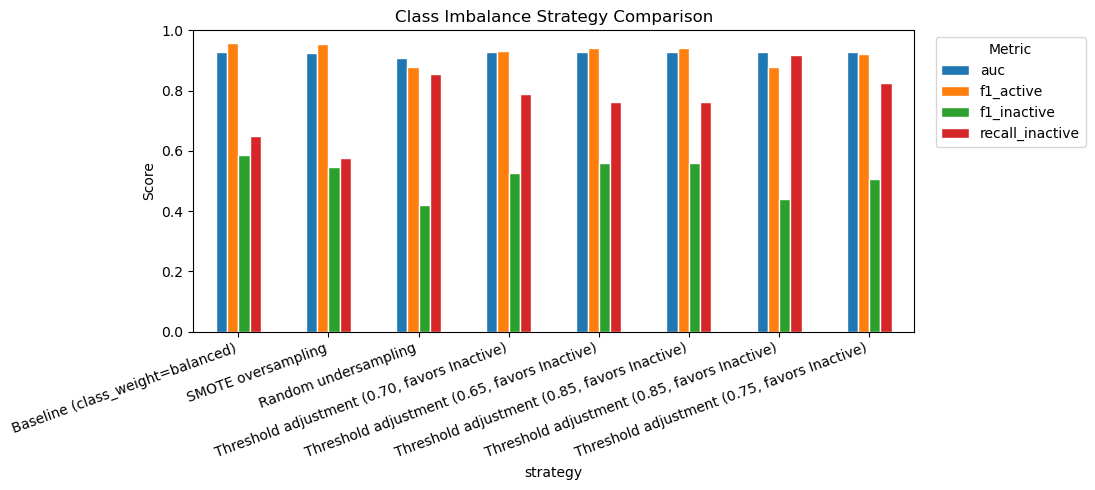

Plot saved to results/


In [14]:
results_df = pd.DataFrame(results).set_index('strategy')
print('=== Strategy Comparison ===')
print(results_df.round(3))

results_df[['auc', 'f1_active', 'f1_inactive', 'recall_inactive']].plot(
    kind='bar', figsize=(11, 5), edgecolor='white'
)
plt.title('Class Imbalance Strategy Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/07_imbalance_strategy_comparison.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 8. Precision-Recall Trade-off for the Threshold Strategy

A closer look at how inactive-class recall and precision trade off as we
move the threshold — useful to justify *why* a specific threshold was chosen.

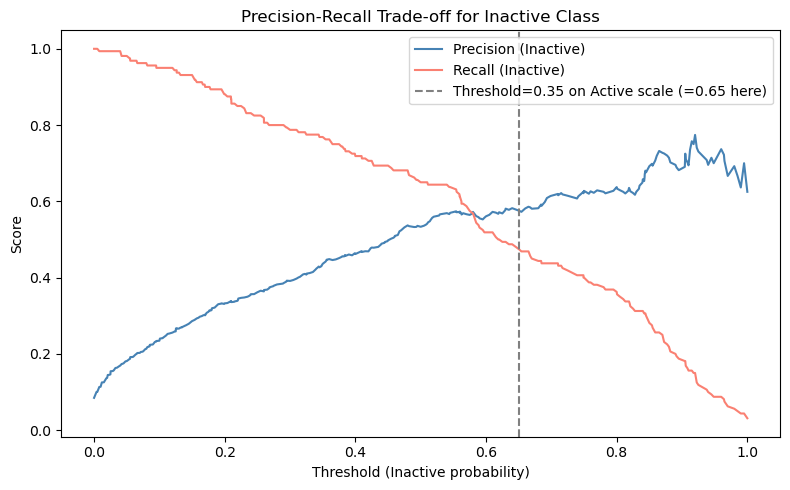

Plot saved to results/


In [15]:
proba_baseline = rf_baseline.predict_proba(X_test)[:, 1]

# precision_recall_curve is defined for the positive class (Active=1).
# To analyze the Inactive class, we invert: treat Inactive as "positive".
precision_inactive, recall_inactive, thresholds = precision_recall_curve(
    1 - y_test, 1 - proba_baseline
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_inactive[:-1], label='Precision (Inactive)', color='steelblue')
plt.plot(thresholds, recall_inactive[:-1], label='Recall (Inactive)', color='salmon')
plt.axvline(x=0.65, color='gray', linestyle='--', label='Threshold=0.35 on Active scale (=0.65 here)')
plt.xlabel('Threshold (Inactive probability)')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off for Inactive Class')
plt.legend()
plt.tight_layout()
plt.savefig('../results/07_precision_recall_tradeoff.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 9. Save Best Strategy

In [16]:
# Identify best strategy by F1 (Inactive) — the metric we're trying to improve
best_strategy = results_df['f1_inactive'].idxmax()
print(f'Best strategy by F1 (Inactive): {best_strategy}')
print(results_df.loc[best_strategy])

# Save whichever model corresponds to the winning strategy
strategy_to_model = {
    'Baseline (class_weight=balanced)': rf_baseline,
    'SMOTE oversampling': rf_smote,
    'Random undersampling': rf_under,
    'Threshold adjustment (0.70, favors Inactive)': rf_baseline
}

best_model = strategy_to_model[best_strategy]
joblib.dump(best_model, '../models/rf_btk_classifier_best_imbalance.pkl')
print(f'\nBest model saved to models/rf_btk_classifier_best_imbalance.pkl')

Best strategy by F1 (Inactive): Baseline (class_weight=balanced)
auc                0.928295
f1_active          0.957335
f1_inactive        0.587571
recall_inactive    0.650000
Name: Baseline (class_weight=balanced), dtype: float64

Best model saved to models/rf_btk_classifier_best_imbalance.pkl


## Observations

### Strategy comparison — no single winner, different trade-offs

| Strategy | AUC | F1 (Inactive) | Recall (Inactive) | F1 (Active) |
|----------|-----|----------------|--------------------|-----------:|
| **Baseline** (`class_weight='balanced'`) | 0.928 | **0.588** | 0.650 | **0.957** |
| SMOTE oversampling | 0.925 | 0.548 | 0.575 | 0.956 |
| Random undersampling | 0.908 | 0.420 | 0.856 | 0.879 |
| Threshold 0.65 | 0.928 | 0.560 | 0.762 | 0.943 |
| Threshold 0.70 | 0.928 | 0.525 | 0.788 | 0.931 |
| Threshold 0.75 | 0.928 | 0.507 | 0.825 | 0.921 |
| Threshold 0.85 | 0.928 | 0.440 | **0.919** | 0.880 |

### What changed compared to the previous dataset

With 91.5% active / 8.5% inactive (vs 82.5/17.5 previously), the class
imbalance is more severe — and this shows clearly in the results. The
baseline F1 Inactive dropped from 0.765 to 0.588, and no strategy was
able to meaningfully recover it. The model simply has too few inactive
examples (802 of 9.436) to learn the inactive pattern with high precision.

### SMOTE and undersampling

**SMOTE** again underperformed the baseline (F1 Inactive 0.548 vs 0.588).
With sparse binary fingerprints, synthetic interpolation between minority-class
points does not produce chemically meaningful examples — confirmed across
both datasets.

**Random undersampling** achieves the highest recall among resampling
strategies (0.856) but at a severe cost: F1 Active drops to 0.879 and
F1 Inactive to 0.420 — worse than the baseline on both counts. Discarding
~6.800 valid active compounds to balance classes is not justified here.

### Threshold adjustment — a continuous trade-off

Unlike resampling strategies, threshold adjustment offers a smooth and
controllable trade-off between F1 Inactive and Recall Inactive, with no
retraining required. The pattern is consistent and predictable:

- Every increase in threshold raises Recall Inactive and lowers F1 Inactive
- No threshold improves both simultaneously
- The optimal choice depends entirely on the downstream use case

### Three models formalized as primary outputs

Rather than a single winner, three configurations are documented:

**1. Baseline (threshold=0.50)** — best overall F1, best F1 Inactive (0.588).
Use when no class is prioritized over the other.

**2. Threshold=0.75** — moderate triage (Recall Inactive 0.825, F1 Inactive
0.507). A reasonable balance for virtual screening where missing some
inactives is acceptable but not ideal.

**3. Threshold=0.85** — conservative triage (Recall Inactive 0.919, F1
Inactive 0.440). Use when the cost of missing a true inactive (wasting
synthesis/assay resources) outweighs the cost of flagging actives as
inactive. Accepts the highest false-inactive rate.

All three use the **same trained model** — only the decision threshold
changes at inference time. No retraining needed.

### Root cause of low inactive performance

With only 802 inactive compounds in the full dataset, the model has
fundamentally limited signal to learn what makes a molecule inactive
against BTK. This is a data problem, not a modeling problem — confirmed
by the fact that neither tuning (notebook 06) nor resampling improved
performance. The highest-leverage next step would be collecting more
experimentally confirmed inactive BTK compounds, not further algorithmic
optimization.


## Summary

| Strategy | AUC | F1 (Active) | F1 (Inactive) | Recall (Inactive) |
|----------|-----|--------------|----------------|--------------------|
| Baseline | *(see output)* | | | |
| SMOTE | *(see output)* | | | |
| Undersampling | *(see output)* | | | |
| Threshold=0.35 | *(see output)* | | | |

**Next:** convert the full pipeline (notebooks 01–07) into reusable `src/` scripts.